In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from Bio import SeqIO
import os
from collections import Counter
import scipy
from scipy.stats import mannwhitneyu, chi2_contingency,ks_2samp,kruskal
from matplotlib.patches import Patch

plt.rcParams.update({'font.family':'Arial'})




In [2]:
base_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/code/'


fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'

In [ ]:
species = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/select_species_for_analysis/shared_species_for_analysis.csv')
species = species.set_index('species_id_VMGC')
species_list = species.index.tolist()
species

,species,species_id_GTDB,num_samples_GTDB,num_samples_VMGC
species_id_VMGC,,,,
988598,Lactobacillus crispatus,100122,135,135
240891,Lactobacillus iners,100505,120,121
783244,Bifidobacterium vaginale,100323,78,78
619501,Fannyhessea vaginae,103895,65,43
571325,Lactobacillus jensenii,100515,35,35
611554,Lactobacillus gasseri,100460,20,20


In [8]:
genome_info = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/combined_db/combined_db_build/combined_genomes_with_database.tsv', sep='\t')
genome_info['species_name'] = genome_info['species'].map(species['species'])

midas_ann_full = pd.read_excel(f'{base_dir}/GTDB/classify_GTDB_sources/six_species_origins.xlsx', index_col=0)
midas_ann_full['species_name'] = midas_ann_full['species'].map(species.reset_index().set_index('species_id_GTDB')['species'])
midas_ann_full = midas_ann_full.drop_duplicates('Assembly Accession')
midas_ann_full = midas_ann_full.set_index('Assembly Accession')

midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('urine','urinary tract')
midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('gastrointestinal','gastrointestinal tract')
midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('female reproductive tract','FRT')


midas_genome_to_source = midas_ann_full['human_subcategory'].to_dict()

In [9]:



def fill_source(row):

    if row['genome'] in  midas_genome_to_source:

        source = midas_genome_to_source[row['genome']]
        if not pd.isna(source):
            return source

    if row['database'] in ['VMGC','shared']:
        return 'FRT'

    else:
        return 'unknown'

genome_info['source'] = genome_info.apply(fill_source, axis=1)
genome_info['source'].value_counts()
    

source
FRT                       4780
urinary tract               58
non-human                   50
gastrointestinal tract      14
unknown                     10
other                        5
respiratory                  4
oral                         2
Name: count, dtype: int64

### Extract annotation info

In [12]:
counts = []

for genome in genome_info['genome'].values:

    ### GENOMAD VIRUS
    genomad_virus = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/genomad_virus/{genome}_virus_summary.tsv'  
    df = pd.read_csv(genomad_virus, sep='\t')

    num_viral_seqs = df.shape[0]
    num_integrated_seqs = df['coordinates'].dropna().shape[0]
    num_non_integrated_seqs = df[df['coordinates'].isna()].shape[0]

    ### GENOMAD PLASMID
    genomad_plasmid = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/genomad_plasmid/{genome}_plasmid_summary.tsv'  
    df = pd.read_csv(genomad_plasmid, sep='\t')
    num_plasmids = df.shape[0]

    # ### DISINFINDER     
    disinfinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/DisinFinder/{genome}_DisinFinder_results_tab.txt'  
    df = pd.read_csv(disinfinder, sep='\t')
    num_disinf = df.shape[0]

    ### RESFINDER     
    resfinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/ResFinder/{genome}_ResFinder_results_tab.txt'  
    df = pd.read_csv(resfinder, sep='\t')
    num_resfinder = df.shape[0]
    num_lsa = df[df['Resistance gene'] == 'lsa(C)'].shape[0]
    num_tet = df[df['Resistance gene'] == 'tet(M)'].shape[0]
    num_erm = df[df['Resistance gene'] == 'erm(B)'].shape[0]

    ### MEFINDER     
    mefinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/mefinder/{genome}_mefinder.csv'  
    df = pd.read_csv(mefinder, comment='#')
    num_IS = df[df['type'] == 'insertion sequence'].shape[0]
    num_transposons = df[df['type'].isin(['ice', 'composite transposon', 'unit transposon'])].shape[0]

    counts += [[genome,num_viral_seqs,num_integrated_seqs,num_non_integrated_seqs,num_plasmids,num_disinf,num_resfinder,num_lsa, num_tet, num_erm, num_IS, num_transposons]]

counts_df = pd.DataFrame(counts)
counts_df.columns = ['genome','num_viral_seqs','num_integrated_seqs','num_non_integrated_seqs','num_plasmids',
                    'num_disinf',
                    'num_resfinder','num_lsa', 'num_tet', 'num_erm','num_IS', 'num_transposons']
counts_df = counts_df.set_index('genome')

counts_df = genome_info.merge(counts_df, left_on='genome', right_index=True)


In [13]:
species_order = ['Lactobacillus crispatus',
                                'Lactobacillus iners',
                                'Lactobacillus jensenii',
                                'Lactobacillus gasseri',
                                'Bifidobacterium vaginale',
                                'Fannyhessea vaginae']

### Plot differences in number of annotated features per category

In [15]:
def make_broad_categories(source):

    if source == 'FRT' or source == 'non-human':
        return source
    if source in ['urinary tract','gastrointestinal tract', 'other','respiratory', 'oral']:
        return 'all human, non-FRT'
    else:
        return 'unknown'
    
def make_human_nonhuman(source):

    if source == 'non-human':
        return source
    if source in ['FRT', 'urinary tract','gastrointestinal tract', 'other','respiratory', 'oral']:
        return 'human'
    else:
        return 'unknown'


genome_info['broad_source'] = genome_info['source'].apply(make_broad_categories)
genome_info['human_nonhuman'] = genome_info['source'].apply(make_human_nonhuman)

genome_info[['species_name','broad_source']].value_counts().sort_index()



species_name              broad_source      
Bifidobacterium vaginale  FRT                    714
                          all human, non-FRT      18
                          unknown                  1
Fannyhessea vaginae       FRT                    787
Lactobacillus crispatus   FRT                    870
                          all human, non-FRT      20
                          non-human               50
Lactobacillus gasseri     FRT                    203
                          all human, non-FRT      19
                          unknown                  5
Lactobacillus iners       FRT                   1879
                          all human, non-FRT       7
                          unknown                  1
Lactobacillus jensenii    FRT                    327
                          all human, non-FRT      19
                          unknown                  3
Name: count, dtype: int64

In [16]:
counts_df['broad_source'] = counts_df['genome'].map(genome_info.set_index('genome')['broad_source'])
counts_df['human_nonhuman'] = counts_df['genome'].map(genome_info.set_index('genome')['human_nonhuman'])

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16477/395930715.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16477/395930715.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16477/395930715.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_16477/395930715.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of tic

num_viral_seqs VMGC shared 0.004082325564447519
num_viral_seqs VMGC GTDB 0.0012089818587186095
num_viral_seqs shared GTDB 3.782228842057744e-06
num_viral_seqs human/non-human 1.1390521706386961e-05
num_viral_seqs FRT vs. gastrointestinal tract 0.012587869187263701
num_viral_seqs FRT vs. urinary tract 0.842553749738891
num_viral_seqs FRT vs. all human, non-FRT 0.014103642403113523
num_integrated_seqs VMGC shared 2.2095555393943662e-07
num_integrated_seqs VMGC GTDB 0.11732112591549387
num_integrated_seqs shared GTDB 4.114570835037112e-06
num_integrated_seqs human/non-human 4.0532732240484465e-05
num_integrated_seqs FRT vs. gastrointestinal tract 0.04052508587824669
num_integrated_seqs FRT vs. urinary tract 0.43126922437415627
num_integrated_seqs FRT vs. all human, non-FRT 0.13554847599696077
num_non_integrated_seqs VMGC shared 0.3028886809368506
num_non_integrated_seqs VMGC GTDB 0.011327820805576209
num_non_integrated_seqs shared GTDB 0.013701353099137966
num_non_integrated_seqs human/no

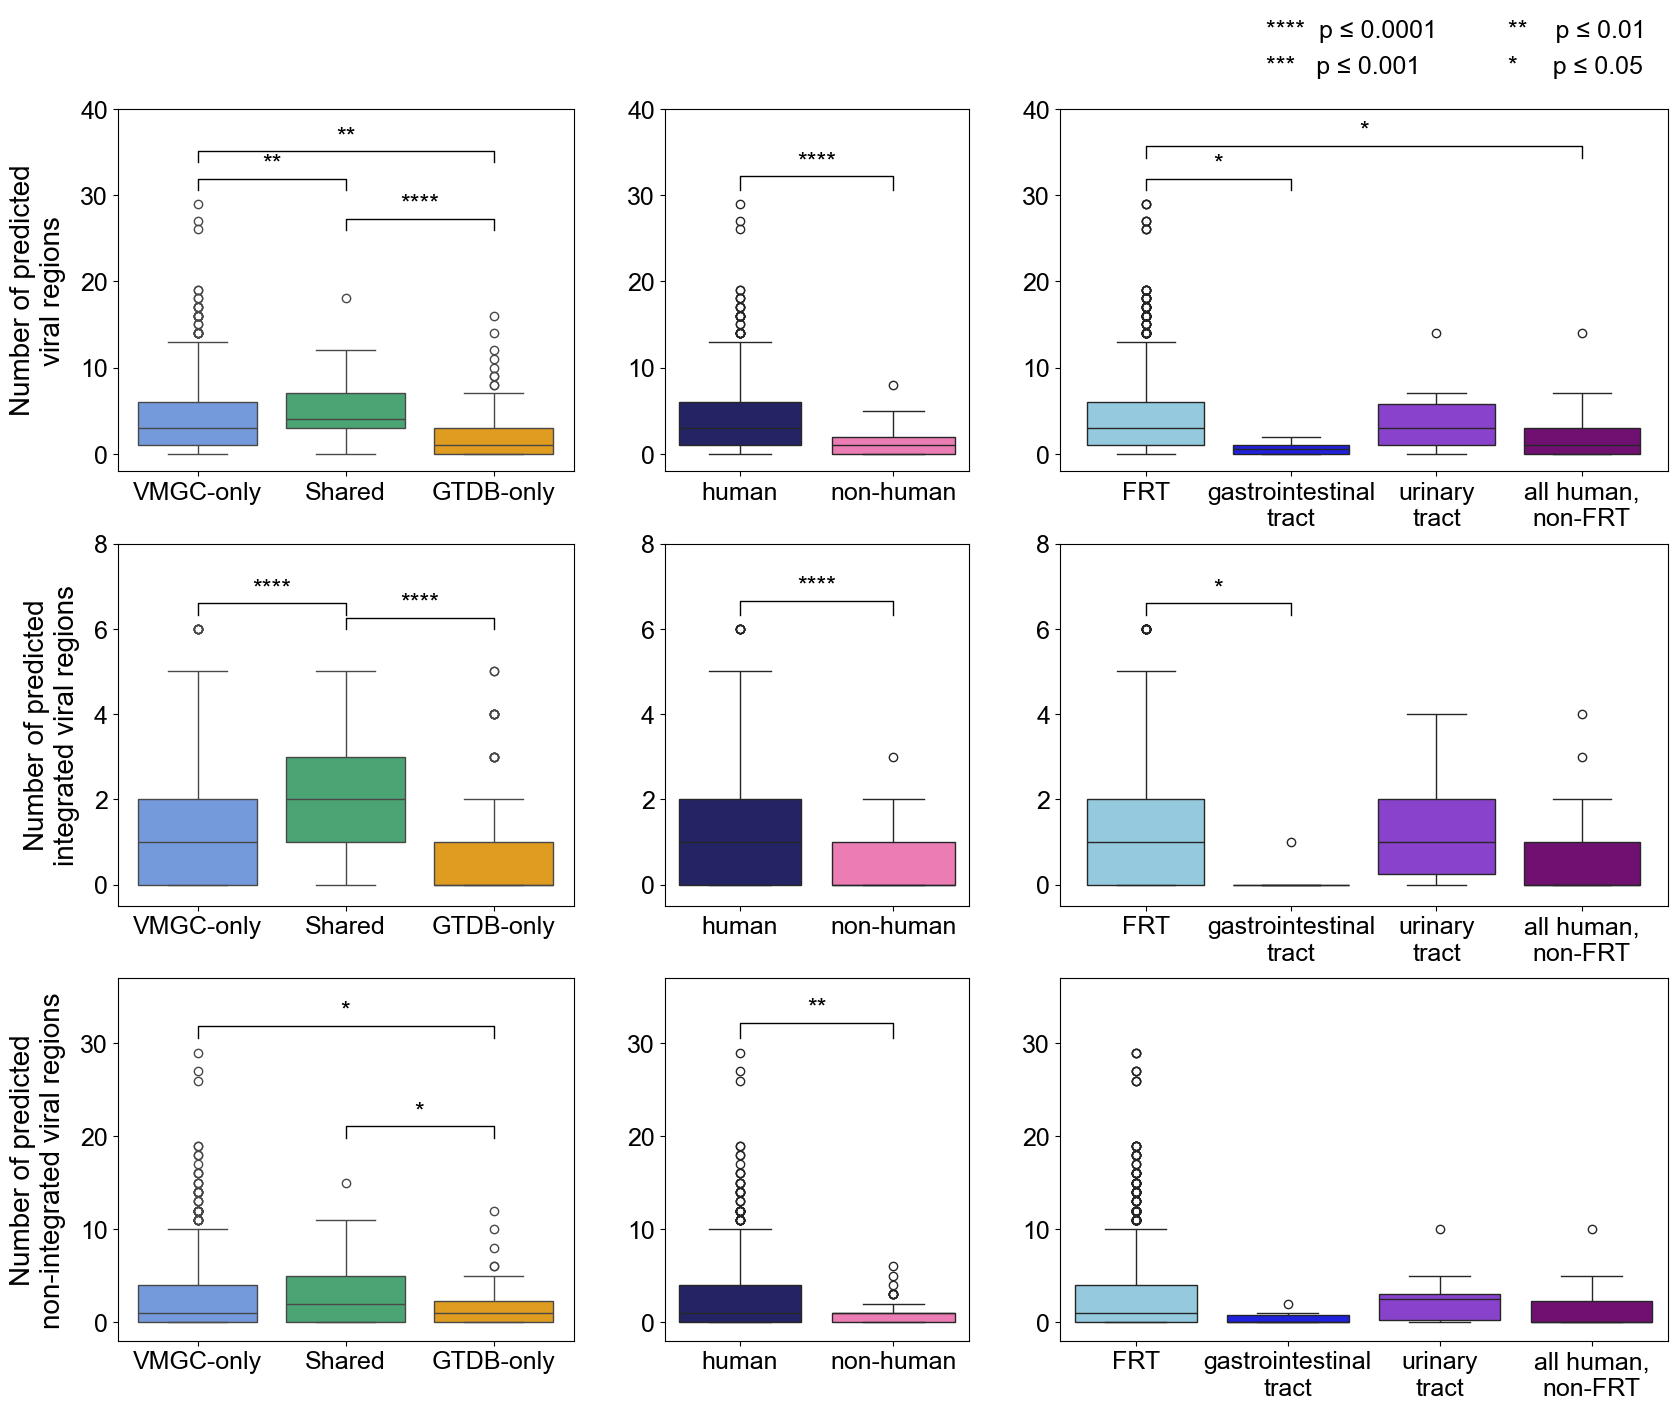

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
import pandas as pd

# Subset just Lactobacillus crispatus
df = counts_df[counts_df['species_name'] == 'Lactobacillus crispatus']

# Colors
my_pal = {
    "human": "midnightblue",
    "non-human": "hotpink",
    "FRT": "skyblue",
    "all human, non-FRT": "purple",
    "urinary tract": "blueviolet",
    "gastrointestinal tract": "blue",
}
db_pal = {"VMGC": "cornflowerblue", "shared": "mediumseagreen", "GTDB": "orange"}
db_order = ["VMGC", "shared", "GTDB"]

col_names = {
    "num_viral_seqs": "Number of predicted viral regions",
    "num_integrated_seqs": "Number of predicted integrated viral regions",
    "num_non_integrated_seqs": "Number of predicted non-integrated viral regions",
}

# Function to convert p-value to stars
def p_to_stars(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

# Define comparisons exactly as in your code
comparisons = {
    "Human vs. Non-human": ("human_nonhuman", ["human", "non-human"]),
    "FRT vs. GI": ("source", ["FRT", "gastrointestinal tract"]),
        "FRT vs. Urine": ("source", ["FRT", "urinary tract"]),
    "FRT vs. non-FRT human": ("broad_source", ["FRT", "all human, non-FRT"]),

}

# Create 3 rows × 3 cols
fig, axs = plt.subplots(3, 3, figsize=(20, 16), gridspec_kw={'width_ratios': [3, 2, 4]})
axs = axs.flatten()

for i, metric in enumerate(["num_viral_seqs", "num_integrated_seqs", "num_non_integrated_seqs"]):
    # --- Leftmost: Database comparison ---
    ax_db = axs[i*3]
    sns.boxplot(
        data=df[df["database"].isin(db_order)],
        x="database",
        y=metric,
        palette=db_pal,
        order=db_order,
        ax=ax_db,
    )
    # Pairwise comparisons for database
    vals_db = {grp: df[df["database"] == grp][metric].dropna().tolist() for grp in db_order}
    pad = 0.05 * (ax_db.get_ylim()[1] - ax_db.get_ylim()[0])
    offset = 0
    for j1 in range(len(db_order)):
        for j2 in range(j1+1, len(db_order)):
            vals1, vals2 = vals_db[db_order[j1]], vals_db[db_order[j2]]
            if len(vals1) >= 5 and len(vals2) >= 5:
                mwu = mannwhitneyu(vals1, vals2, alternative="two-sided")
                label = p_to_stars(mwu.pvalue)
                print(metric, db_order[j1], db_order[j2], mwu.pvalue)

                if label != "ns":
                    base_y = max(max(vals1), max(vals2))
                    bracket_height = base_y + pad*(offset+1)
                    ax_db.plot([j1, j1, j2, j2],
                               [bracket_height, bracket_height + pad*0.8,
                                bracket_height + pad*0.8, bracket_height],
                               color="k", linewidth=1.0)
                    ax_db.text((j1+j2)/2, bracket_height + pad*1.0, label,
                               ha="center", va="bottom", fontsize=18)
                    offset += 2
    ax_db.set_ylabel(col_names[metric])
    ax_db.set_xlabel("")
    ax_db.set_xticks(ax_db.get_xticks(), labels=['VMGC-only','Shared','GTDB-only'])


    # --- Middle: Human vs Non-human ---
    ax_left = axs[i*3 + 1]
    col, groups = comparisons["Human vs. Non-human"]
    sns.boxplot(
        data=df[df[col].isin(groups)],
        x=col,
        y=metric,
        palette=my_pal,
        order=groups,
        ax=ax_left,
    )
    vals1 = df[df[col] == groups[0]][metric].dropna().tolist()
    vals2 = df[df[col] == groups[1]][metric].dropna().tolist()
    if len(vals1) >= 5 and len(vals2) >= 5:
        mwu = mannwhitneyu(vals1, vals2, alternative="two-sided")
        label = p_to_stars(mwu.pvalue)
        print(metric, 'human/non-human', mwu.pvalue)
        if label != "ns":
            base_y = max(max(vals1), max(vals2))
            pad = 0.05 * (ax_left.get_ylim()[1] - ax_left.get_ylim()[0])
            bracket_height = base_y + pad
            ax_left.plot([0, 0, 1, 1],
                         [bracket_height, bracket_height + pad, bracket_height + pad, bracket_height],
                         color="k", linewidth=1.0)
            ax_left.text(0.5, bracket_height + pad*1.2, label,
                         ha="center", va="bottom", fontsize=18)
    ax_left.set_ylabel(col_names[metric])
    ax_left.set_xlabel("")

    # --- Right: Combined FRT comparisons ---
    ax_right = axs[i*3 + 2]
    order = ["FRT",  "gastrointestinal tract",  "urinary tract", "all human, non-FRT",]
    df_combined = []
    for comp_name, (c, grps) in comparisons.items():
        if comp_name == "Human vs. Non-human":
            continue
        sub = df[df[c].isin(grps)].copy()
        sub["comparison_group"] = sub[c]
        df_combined.append(sub)
    df_combined = pd.concat(df_combined, axis=0)
    sns.boxplot(
        data=df_combined[df_combined["comparison_group"].isin(order)],
        x="comparison_group",
        y=metric,
        palette=my_pal,
        order=order,
        ax=ax_right,
    )
    vals_frt = df_combined[df_combined["comparison_group"] == "FRT"][metric].dropna().tolist()
    for j, group in enumerate(order[1:]):
        vals2 = df_combined[df_combined["comparison_group"] == group][metric].dropna().tolist()
        if len(vals_frt) >= 5 and len(vals2) >= 5:
            mwu = mannwhitneyu(vals_frt, vals2, alternative="two-sided")
            label = p_to_stars(mwu.pvalue)
            print(metric, 'FRT vs.', group, mwu.pvalue)
            if label != "ns":
                base_y = max(max(vals_frt), max(vals2))
                pad = 0.05 * (ax_right.get_ylim()[1] - ax_right.get_ylim()[0])
                bracket_height = base_y + pad*(j+1)
                x1, x2 = 0, order.index(group)
                ax_right.plot([x1, x1, x2, x2],
                              [bracket_height, bracket_height + pad*0.8,
                               bracket_height + pad*0.8, bracket_height],
                              color="k", linewidth=1.0)
                ax_right.text((x1+x2)/2, bracket_height + pad*1.0, label,
                              ha="center", va="bottom", fontsize=18)
    ax_right.set_ylabel("")
    ax_right.set_xlabel("")
    ax_right.set_xticklabels([i.get_text().replace(' tract', '\ntract', 1).replace(', ',',\n') for i in ax_right.get_xticklabels()], rotation=0, ha="center", fontsize=14)

    # Axis limits
    if i == 0:
        ax_db.set_ylim(-2, 40); ax_left.set_ylim(-2, 40); ax_right.set_ylim(-2, 40)
  

    if i == 1:
        ax_db.set_ylim(-0.5, 8); ax_left.set_ylim(-0.5, 8); ax_right.set_ylim(-0.5, 8)
    if i == 2:
        ax_db.set_ylim(-2, 37); ax_left.set_ylim(-2, 37); ax_right.set_ylim(-2, 37)

    ax_db.set_ylabel(col_names[metric].replace('predicted ', 'predicted\n'), labelpad=10, fontsize=20)
    ax_left.set_ylabel('')
    ax_right.set_ylabel('')

    ax_db.tick_params(axis='both', which='major', labelsize=18)
    ax_left.tick_params(axis='both', which='major', labelsize=18)
    ax_right.tick_params(axis='both', which='major', labelsize=18)

    # ax_db.tick_params(axis='y', which='major', labelsize=20)


# Legend
legend_elements = [
    Patch(facecolor="white", edgecolor="none", label="****  p ≤ 0.0001"),
    Patch(facecolor="white", edgecolor="none", label="***   p ≤ 0.001"),
    Patch(facecolor="white", edgecolor="none", label="**    p ≤ 0.01"),
    Patch(facecolor="white", edgecolor="none", label="*     p ≤ 0.05"),
]
fig.legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=18,
        #    title="Mann–Whitney U test",
            bbox_to_anchor=(0.9, 0.95), ncols=2, columnspacing=0.01, title_fontsize=18)



plt.subplots_adjust(wspace=0.2)
plt.savefig(f'{fig_dir}/figure_S4.png', format='png', dpi=600, bbox_inches="tight")

plt.show()
